In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import dbm_to_w, w_to_dbm
from rfmodel.meas.spectrum_analyser import spectrum_analyser
from rfmodel.plot_utils.spectrum_plot import plot_top_spectrum

import rfmodel.rf.registry


cfg = load_yaml(r".\PA_test.yaml")
pipe = pipeline_from_config(cfg)

In [2]:
fs = 5_000_000
fc = 1e9
f0 = 50_000
dur = 0.02
t = np.arange(0, dur, 1 / fs)


# ------------------------------------------------------------
# 1) Small-signal gain check
# ------------------------------------------------------------
Pin_dbm = 0.0
Pin_W = dbm_to_w(Pin_dbm)

A = np.sqrt(Pin_W)
x_in = A * np.exp(1j * 2 * np.pi * f0 * t)

sig_in = Signal(
    x=x_in,
    fs_hz=fs,
    fc_hz=fc,
    meta={"Pin_dbm": Pin_dbm},
)

sig_out, taps = pipe.run(sig_in, taps=["pa1"])


In [3]:
Pin_meas_W = np.mean(np.abs(sig_in.x) ** 2)
Pout_meas_W = np.mean(np.abs(sig_out.x) ** 2)

G_lin = Pout_meas_W / Pin_meas_W
G_db = 10 * np.log10(G_lin)

print("=== Small-signal test ===")
print("Input power  (W):  ", Pin_meas_W)
print("Input power  (dBm):", w_to_dbm(Pin_meas_W))
print("Output power (W):  ", Pout_meas_W)
print("Output power (dBm):", w_to_dbm(Pout_meas_W))
print("Measured gain (dB):", G_db)


=== Small-signal test ===
Input power  (W):   0.0009999999999999994
Input power  (dBm): -2.8929823996598624e-15
Output power (W):   0.099995676005644
Output power (dBm): 19.999812207251036
Measured gain (dB): 19.99981220725104


In [4]:
# ------------------------------------------------------------
# 2) Compression sweep
# ------------------------------------------------------------
Pin_sweep_dbm = np.linspace(-30, 20, 51)
Pout_sweep_dbm = []
Gain_sweep_db = []
Pout_ideal_dbm = []

for Pin_dbm_i in Pin_sweep_dbm:
    Pin_W_i = dbm_to_w(Pin_dbm_i)
    A_i = np.sqrt(Pin_W_i)

    x_i = A_i * np.exp(1j * 2 * np.pi * f0 * t)
    sig_i = Signal(
        x=x_i,
        fs_hz=fs,
        fc_hz=fc,
        meta={"Pin_dbm": Pin_dbm_i},
    )

    sig_o, _ = pipe.run(sig_i)

    Pin_meas_i_W = np.mean(np.abs(sig_i.x) ** 2)
    Pout_meas_i_W = np.mean(np.abs(sig_o.x) ** 2)

    Pin_meas_i_dbm = w_to_dbm(Pin_meas_i_W)
    Pout_meas_i_dbm = w_to_dbm(Pout_meas_i_W)
    Gain_i_db = Pout_meas_i_dbm - Pin_meas_i_dbm

    Pout_sweep_dbm.append(Pout_meas_i_dbm)
    Gain_sweep_db.append(Gain_i_db)

# Estimate small-signal gain from first sweep point
G_small_db = Gain_sweep_db[0]

for Pin_dbm_i in Pin_sweep_dbm:
    Pout_ideal_dbm.append(Pin_dbm_i + G_small_db)

Pout_sweep_dbm = np.array(Pout_sweep_dbm)
Gain_sweep_db = np.array(Gain_sweep_db)
Pout_ideal_dbm = np.array(Pout_ideal_dbm)

compression_db = Pout_ideal_dbm - Pout_sweep_dbm
idx_1db = np.argmin(np.abs(compression_db - 1.0))

print("\n=== Compression sweep ===")
print("Estimated small-signal gain (dB):", G_small_db)
print("Estimated output P1dB (dBm):", Pout_sweep_dbm[idx_1db])
print("Estimated input  P1dB (dBm):", Pin_sweep_dbm[idx_1db])
print("Compression at that point (dB):", compression_db[idx_1db])


=== Compression sweep ===
Estimated small-signal gain (dB): 20.0
Estimated output P1dB (dBm): 26.999999999999996
Estimated input  P1dB (dBm): 8.0
Compression at that point (dB): 1.0000000000000036


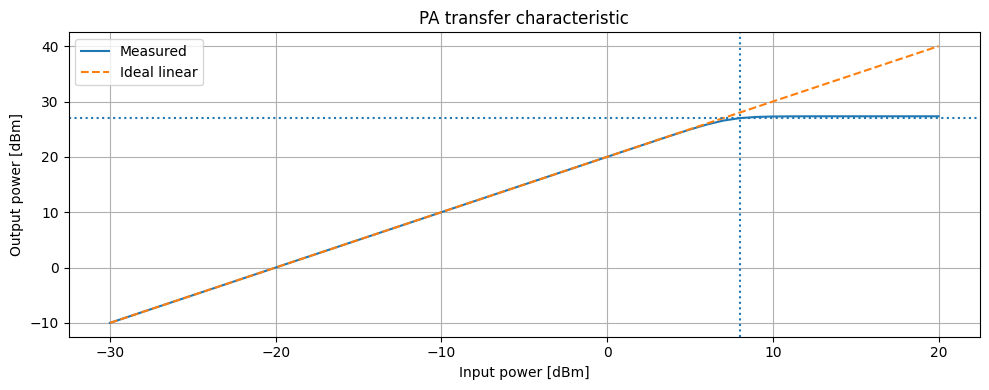

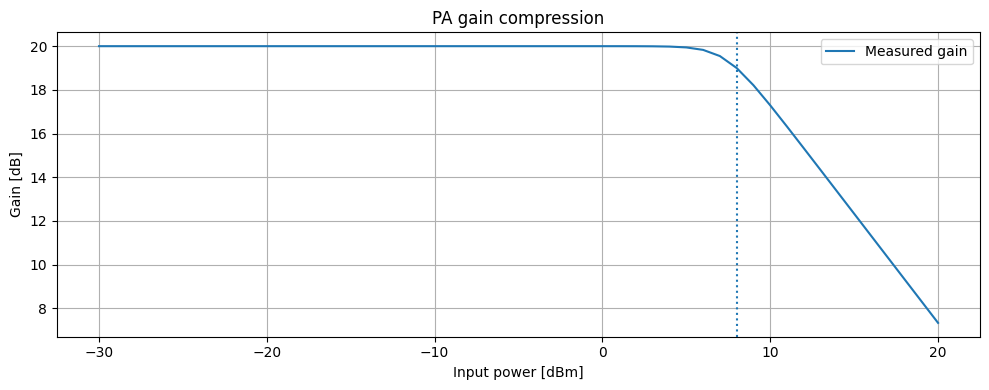

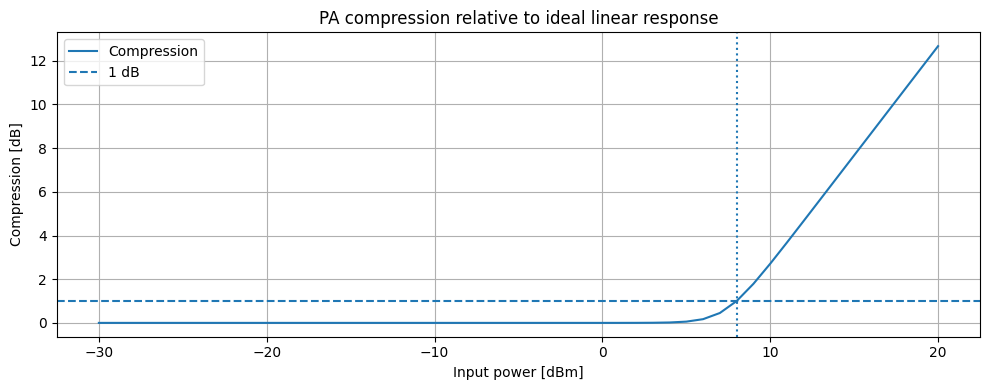

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(Pin_sweep_dbm, Pout_sweep_dbm, label="Measured")
plt.plot(Pin_sweep_dbm, Pout_ideal_dbm, "--", label="Ideal linear")
plt.axvline(Pin_sweep_dbm[idx_1db], linestyle=":")
plt.axhline(Pout_sweep_dbm[idx_1db], linestyle=":")
plt.xlabel("Input power [dBm]")
plt.ylabel("Output power [dBm]")
plt.title("PA transfer characteristic")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(Pin_sweep_dbm, Gain_sweep_db, label="Measured gain")
plt.axvline(Pin_sweep_dbm[idx_1db], linestyle=":")
plt.xlabel("Input power [dBm]")
plt.ylabel("Gain [dB]")
plt.title("PA gain compression")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(Pin_sweep_dbm, compression_db, label="Compression")
plt.axhline(1.0, linestyle="--", label="1 dB")
plt.axvline(Pin_sweep_dbm[idx_1db], linestyle=":")
plt.xlabel("Input power [dBm]")
plt.ylabel("Compression [dB]")
plt.title("PA compression relative to ideal linear response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
